# AT&T DistilBERT (PyTorch)

In [1]:
# 🛡️ Détection de Spam SMS avec DistilBERT (PyTorch) - Version M4 stable

import os
import time
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.optim import AdamW
from transformers import get_scheduler
from torch.utils.data import DataLoader
from tqdm import tqdm

# ----------------------------
# Hyperparamètres
EPOCHS = 15
BATCH_SIZE = 16
LR = 2e-5
OUTPUT_DIR = "./distilbert_AT&T"
# ----------------------------

# --- Device ---
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)

# --- Optimisation sûre float32 ---
try:
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision:", torch.get_float32_matmul_precision())
except Exception as e:
    print("Matmul precision setting not available:", e)

# AMP uniquement pour CUDA
from torch.cuda.amp import autocast, GradScaler
use_amp = (device.type == "cuda")
scaler = GradScaler() if use_amp else None


2025-09-02 16:08:57.628998: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: cpu
float32 matmul precision: medium


In [2]:
# 1. Chargement et nettoyage des données
url = "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv"
df = pd.read_csv(url, encoding='Windows-1252')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df['label'] = df['label'].replace({'ham': 0, 'spam': 1})

/var/folders/mk/k32g1gsn4c1_yd1vbqdbpvw00000gn/T/ipykernel_41976/3927115337.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'ham': 0, 'spam': 1})


In [3]:
df

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


# Nettoyage avancé, et création de patterns spécifiques au Spam

In [ ]:
import re
import emoji
from typing import Optional, List
import string

# --- Classe TextCleanerTransferLearning ---
class TextCleanerTransferLearning:
    """
    Nettoyeur de texte optimisé pour le transfer learning avec DistilBERT.
    Préserve la structure sémantique tout en normalisant le contenu.
    """
    def __init__(self, preserve_case: bool = True, max_length: int = 512):
        self.preserve_case = preserve_case
        self.max_length = max_length

        # Patterns compilés pour de meilleures performances
        self.url_pattern = re.compile(r"http[s]?://\S+|www\.\S+|[\w-]+\.(?:com|org|net|edu|gov|co\.uk|fr)\b", re.IGNORECASE)
        self.email_pattern = re.compile(r"\b[\w.-]+@[\w.-]+\.\w+\b")
        self.phone_pattern = re.compile(r"(?:\+?\d{1,3}[-.\s]?)?\(?\d{2,4}\)?[-.\s]?\d{2,4}[-.\s]?\d{2,4}")
        self.money_pattern = re.compile(r"\$\d+(?:[.,]\d{2})?|\b\d+\s*(?:USD|EUR|dollars?|euros?|bucks?|k|K)\b", re.IGNORECASE)
        self.number_pattern = re.compile(r"\b\d{4,}\b")
        self.hashtag_pattern = re.compile(r"#\w+")
        self.mention_pattern = re.compile(r"@\w+")

        # Patterns spam spécifiques
        self.spam_actions = re.compile(r"\bcl(?:ick|ik|ic+k?)\b", re.IGNORECASE)
        self.spam_words = re.compile(r"\b(free|win|prize|winner|congratulations?|urgent|limited|offer|deal)\b", re.IGNORECASE)

        # Nettoyage des répétitions
        self.repeat_chars = re.compile(r"([!?.])\1{2,}")
        self.repeat_letters = re.compile(r"\b(\w)\1{4,}")

        # Espaces multiples
        self.multi_space = re.compile(r"\s+")

        # Caractères à préserver
        self.valid_chars = re.compile(r"[^\w\s'\"!?.,;:()\-<>/@#]")

    def clean_text_transfer_learning(self, text: str) -> str:
        if not isinstance(text, str) or not text.strip():
            return ""

        text = text.strip()

        # 1. Gestion de la longueur
        words = text.split()
        if len(words) > 350:
            truncated_text = ' '.join(words[:350])
            last_sentence = max(truncated_text.rfind('.'), truncated_text.rfind('!'), truncated_text.rfind('?'))
            if last_sentence > len(truncated_text) * 0.7:
                text = truncated_text[:last_sentence + 1]
            else:
                text = truncated_text

        # 2. Normalisation des espaces
        text = self.multi_space.sub(" ", text)

        # 3. Remplacement par tokens spéciaux
        text = self.url_pattern.sub(" urltoken ", text)
        text = self.email_pattern.sub(" emailtoken ", text)
        text = self.phone_pattern.sub(" phonetoken ", text)
        text = self.money_pattern.sub(" moneytoken ", text)
        text = self.number_pattern.sub(" numtoken ", text)
        text = self.hashtag_pattern.sub(" hashtagtoken ", text)
        text = self.mention_pattern.sub(" mentiontoken ", text)

        # 4. Tokens spam
        text = self.spam_actions.sub(" clicktoken ", text)
        text = self.spam_words.sub(lambda m: f" spam{m.group(0).lower()}token ", text)

        # 5. Conversion emojis
        text = emoji.demojize(text, delimiters=("", ""))
        text = re.sub(r":([a-z_]+):", r" \1 ", text)
        text = text.replace("_", " ")

        # 6. Nettoyage des répétitions
        text = self.repeat_chars.sub(r"\1\1", text)
        text = self.repeat_letters.sub(r"\1\1\1", text)

        # 7. Suppression des caractères non valides
        text = self.valid_chars.sub(" ", text)

        # 8. Normalisation de la casse (optionnel pour DistilBERT-uncased)
        if not self.preserve_case:
            text = text.lower()

        # 9. Normalisation finale des espaces
        text = self.multi_space.sub(" ", text).strip()

        # 10. Isolation des tokens spéciaux
        text = re.sub(r"([a-z]+token)", r" \1 ", text)
        text = self.multi_space.sub(" ", text).strip()

        return text

# --- Fonction optimisée pour DistilBERT ---
def clean_text_distilbert_optimized(text: str, max_length: int = 350) -> str:
    cleaner = TextCleanerTransferLearning(preserve_case=True, max_length=max_length)
    text = cleaner.clean_text_transfer_learning(text)

    # Remplacement des tokens par des versions plus courtes et standardisées
    text = text.replace("urltoken", "[URL]")
    text = text.replace("emailtoken", "[EMAIL]")
    text = text.replace("phonetoken", "[PHONE]")
    text = text.replace("moneytoken", "[MONEY]")
    text = text.replace("numtoken", "[NUM]")
    text = text.replace("hashtagtoken", "[HASHTAG]")
    text = text.replace("mentiontoken", "[MENTION]")
    text = text.replace("clicktoken", "[CLICK]")

    # Remplacement des mots spam par un token générique
    text = re.sub(r"spam\w+token", "[SPAM]", text)

    # Nettoyage final des espaces
    text = re.sub(r"\s+", " ", text).strip()

    return text



In [ ]:
df["text"] = df["text"].astype(str)

# Applique la fonction avec une progress bar 
from tqdm import tqdm
tqdm.pandas()
df_backup = df.copy()  # Sauvegarde
df["text"] = df["text"].astype(str).apply(clean_text_distilbert_optimized)


In [25]:
df

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar.. Joking wif u oni..
2,1,[SPAM] entry in 2 a wkly comp to [SPAM] FA Cup...
3,0,U dun say so early hor.. U c already then say..
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì b going to esplanade fr home?
5569,0,"Pity, was in mood for that. So..any other sugg..."
5570,0,The guy did some bitching but I acted like i'd...


# DistilBert


Map: 100%|██████████| 1672/1672 [00:00<00:00, 38622.26 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 6345/6345 [30:04<00:00,  3.49it/s]


✅ Entraînement terminé en 30 min 4 s
Exemples (pred -> label): [(np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0))]


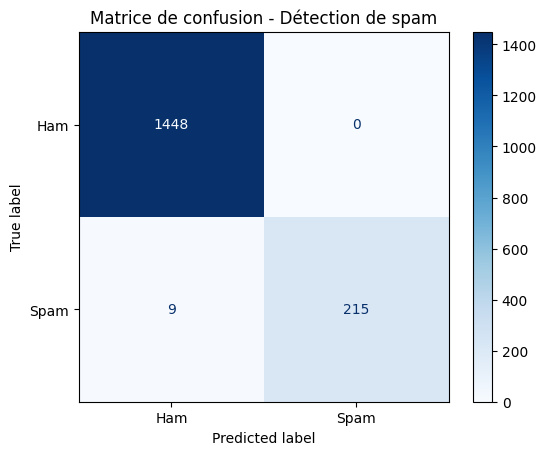


📊 Rapport de classification :
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00      1448
        Spam       1.00      0.96      0.98       224

    accuracy                           0.99      1672
   macro avg       1.00      0.98      0.99      1672
weighted avg       0.99      0.99      0.99      1672


🎯 Précision globale sur le test : 0.9946

⏱️ Temps total entraînement + évaluation : 30 min 11 s
🔖 Sauvegarde du modèle et tokenizer dans ./distilbert_AT&T ...
✅ Sauvegarde terminée.


In [ ]:
# --- Split Train / Test ---
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

# ---  Oversampling du train uniquement ---
train_ham = train_df[train_df.label == 0]
train_spam = train_df[train_df.label == 1]

# Sur-échantillonnage uniquement sur le train
train_spam_upsampled = resample(
    train_spam,
    replace=True,
    n_samples=len(train_ham),
    random_state=42
)

# Créer un train équilibré
train_balanced = pd.concat([train_ham, train_spam_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Le test reste **inchangé et non dupliqué**
test_df = test_df.reset_index(drop=True)  # juste pour sécurité

train_dataset = Dataset.from_pandas(train_balanced.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
dataset = DatasetDict({'train': train_dataset, 'test': test_dataset})

for split in ['train', 'test']:
    if '__index_level_0__' in dataset[split].column_names:
        dataset[split] = dataset[split].remove_columns('__index_level_0__')

# 4. Tokenisation
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True, max_length=512)

tokenized_dataset = dataset.map(preprocess_function, batched=True)

# 5. Modèle
id2label = {0: "ham", 1: "spam"}
label2id = {"ham": 0, "spam": 1}
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)  # float32 sur MPS pour stabilité

# 6. DataCollator & formatage
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

def rename_and_format(dataset_part):
    ds = dataset_part.map(lambda examples: {"labels": examples["label"]}, batched=True)
    cols = [c for c in tokenized_dataset['train'].column_names if c not in ['text']] + ['labels']
    ds.set_format(type='torch', columns=cols)
    return ds

pt_train = rename_and_format(tokenized_dataset['train'])
pt_test = rename_and_format(tokenized_dataset['test'])

train_dataloader = DataLoader(pt_train, shuffle=True, batch_size=BATCH_SIZE, collate_fn=data_collator)
eval_dataloader = DataLoader(pt_test, batch_size=BATCH_SIZE, collate_fn=data_collator)

# 7. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LR)
num_training_steps = EPOCHS * len(train_dataloader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

progress_bar = tqdm(range(num_training_steps))

# 8. Entraînement
start_time = time.time()
model.train()
for epoch in range(EPOCHS):
    for batch in train_dataloader:
        if 'labels' in batch:
            batch['labels'] = batch['labels'].long()
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k,v in batch.items()}

        optimizer.zero_grad()
        if use_amp:
            with autocast():
                outputs = model(**batch)
                loss = outputs.loss
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

        lr_scheduler.step()
        progress_bar.update(1)

train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {int(train_time//60)} min {int(train_time%60)} s")

# 9. Évaluation
model.eval()
preds, labels_list = [], []
with torch.no_grad():
    for batch in eval_dataloader:
        if 'labels' in batch:
            batch['labels'] = batch['labels'].long()
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k,v in batch.items()}

        if use_amp:
            with autocast():
                outputs = model(**batch)
        else:
            outputs = model(**batch)

        logits_cpu = outputs.logits.detach().to("cpu")
        batch_preds = torch.argmax(logits_cpu, dim=-1).numpy()
        preds.extend(batch_preds)

        labels_cpu = batch['labels'].detach().to("cpu").numpy()
        labels_list.extend(labels_cpu)

# Debug : premières prédictions
print("Exemples (pred -> label):", list(zip(preds[:10], labels_list[:10])))

# Matrice de confusion
cm = confusion_matrix(labels_list, preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"]).plot(cmap='Blues', values_format='d')
plt.title("Matrice de confusion - Détection de spam")
plt.show()

print("\n📊 Rapport de classification :")
print(classification_report(labels_list, preds, target_names=["Ham", "Spam"]))
print(f"\n🎯 Précision globale sur le test : {(np.array(preds) == np.array(labels_list)).mean():.4f}")

total_time = time.time() - start_time
print(f"\n⏱️ Temps total entraînement + évaluation : {int(total_time//60)} min {int(total_time%60)} s")

# 10. Sauvegarde
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"🔖 Sauvegarde du modèle et tokenizer dans {OUTPUT_DIR} ...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("✅ Sauvegarde terminée.")


# Test sur Textes inventés pour l'occasion

In [30]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- Chargement du modèle et tokenizer ---
model_dir = "./distilbert_AT&T"  # ou "./distilbert_spam_model_ATT"

print("Chargement du modèle...")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if getattr(torch, 'mps', None) and torch.mps.is_available() else "cpu")
model.to(device)
model.eval()

# --- Fonction de prédiction ---
def predict_spam(text):
    """
    Prédit si un SMS est 'ham' ou 'spam' avec confiance.
    Retourne : (label, confidence, probabilities)
    """

    # 1. Nettoyage du texte (identique à l'entraînement)
    cleaned_text = clean_text_distilbert_optimized(text)
    # Tokenization
    encoding = tokenizer(
        cleaned_text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    ).to(device)
    
    # Prédiction
    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
    
    # Probabilités via softmax
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    
    # Label prédit
    predicted_id = np.argmax(probabilities)
    confidence = probabilities[predicted_id]
    label = model.config.id2label[predicted_id]
    
    return label, confidence, probabilities

# --- Test sur des spams réalistes ---
realistic_spams = [
"Hey Marty, we have a meeting tomorrow, don't forget it",
    "You have won a $1000 Walmart gift card! Click here to claim now!",
    "Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Urgent: your banck account is compromised. Click here: http://bit.ly/xxx",
    "You have 1 unread message. Reply to unlock: bit.ly/msg123",
    "Security alert: suspicious login from NY. Confirm now: verify-link.com",
    "FREE MONEY! CLAIM YOUR PRIZE NOW! NO LIMIT!",
    "Hello, can we meet tomorrow?",
    "Congratulation, you've won an iphone, clic here now to grab it!",
    "Hello, do we have a meeting today ? Could you call me?",
    "Your just won 500 buck, claim it now, clic here !",
    "Charles, let's work together on this projet.",
    "Hello Aline, why don't you answer to my call ?",
    "Eric, could you schedule a meeting for next week.",
    "Maybe the false negatif is to high. We should improve it.",
    "We are please to announce that you have won an iphone 16, click here : http://shor.lu/122",
    "We offer you 10 grands for you effort. It's a not a big deal for us. Thank you",
    "Your verification code is 123456. Do not share it with anyone.",
    "Hello Eric, i have your answer, call me asap."
]

print("\n🔍 Test sur des SMS réalistes :\n")
for text in realistic_spams:
    label, conf, probs = predict_spam(text)
    print(f"Original: '{text}'")
    print(f"Nettoyé: '{clean_text_distilbert_optimized(text)}'")
    print(f" → {label.upper()} ({conf:.2%}) | ham: {probs[0]:.4f}, spam: {probs[1]:.4f}\n")

Chargement du modèle...

🔍 Test sur des SMS réalistes :

Original: 'Hey Marty, we have a meeting tomorrow, don't forget it'
Nettoyé: 'Hey Marty, we have a meeting tomorrow, don't forget it'
 → HAM (100.00%) | ham: 1.0000, spam: 0.0000

Original: 'You have won a $1000 Walmart gift card! Click here to claim now!'
Nettoyé: 'You have won a [MONEY] Walmart gift card! [CLICK] here to claim now!'
 → SPAM (100.00%) | ham: 0.0000, spam: 1.0000

Original: 'Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.'
Nettoyé: 'Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.'
 → HAM (100.00%) | ham: 1.0000, spam: 0.0000

Original: 'URGENT: Your bank account has been compromised. Verify your details immediately.'
Nettoyé: '[SPAM] : Your bank account has been compromised. Verify your details immediately.'
 → HAM (98.74%) | ham: 0.9874, spam: 0.0126

Original: 'Urgent: your banck account is compromised. Click here: http://bit.ly/xxx'
Nettoyé: '[SPAM] : your banck account is compromi

In [5]:
text = "Urgent : your account banck has been compromised."

# Affiche quelques vrais spams du test
test_spam_examples = test_df[test_df['label'] == 1].sample(5, random_state=42)
for _, row in test_spam_examples.iterrows():
    print(f"SPAM : '{row['text']}'")

SPAM : 'Marvel Mobile Play the official Ultimate Spider-man game (å£4.50) on ur mobile right now. Text SPIDER to 83338 for the game & we ll send u a FREE 8Ball wallpaper'
SPAM : 'FREE for 1st week! No1 Nokia tone 4 ur mobile every week just txt NOKIA to 8077 Get txting and tell ur mates. www.getzed.co.uk POBox 36504 W45WQ 16+ norm150p/tone'
SPAM : 'Someone U know has asked our dating service 2 contact you! Cant Guess who? CALL 09058091854 NOW all will be revealed. PO BOX385 M6 6WU'
SPAM : 'Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.'
SPAM : 'Dear Voucher Holder 2 claim your 1st class airport lounge passes when using Your holiday voucher call 08704439680. When booking quote 1st class x 2'


In [6]:
test_df.to_csv("test_dataset.csv", index=False)

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import classification_report

# 1. Charger le CSV de test
test_df = pd.read_csv("test_dataset.csv")

# 2. Charger tokenizer et modèle (ajuste le chemin)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("./distilbert_AT&T")

# 3. Préparer le device 
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()

# 4. Tokenizer les textes du test
texts = test_df["text"].tolist()
labels = test_df["label"].tolist()

encodings = tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
input_ids = encodings["input_ids"].to(device)
attention_mask = encodings["attention_mask"].to(device)

# 5. Faire des prédictions batch par batch si besoin (ici tout d’un coup)
with torch.no_grad():
    outputs = model(input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1).cpu().numpy()

# 6. Afficher le rapport
print(classification_report(labels, predictions, digits=4))


              precision    recall  f1-score   support

           0     0.9931    1.0000    0.9966      1448
           1     1.0000    0.9554    0.9772       224

    accuracy                         0.9940      1672
   macro avg     0.9966    0.9777    0.9869      1672
weighted avg     0.9941    0.9940    0.9940      1672



In [ ]:
import numpy as np

preds = np.array(preds)
labels_list = np.array(labels_list)

# Récupérer les indices des erreurs
fp_indices = np.where((preds == 1) & (labels_list == 0))[0]
fn_indices = np.where((preds == 0) & (labels_list == 1))[0]

# Récupérer les textes correspondants depuis test_df

test_texts = test_df['text'].values  # Doit être dans le même ordre que les batchs

print("🔍 FAUX POSITIFS (Ham mal classés comme Spam) :\n")
for i, idx in enumerate(fp_indices):
    if idx < len(test_texts):  # Sécurité
        print(f"[FP {i+1}] Texte : '{test_texts[idx]}'")
        print(f"        Vrai: Ham (0) | Prédit: Spam ({preds[idx]})\n")

print("\n" + "="*60 + "\n")

print("🔍 FAUX NÉGATIFS (Spam mal classés comme Ham) :\n")
for i, idx in enumerate(fn_indices):
    if idx < len(test_texts):  # Sécurité
        print(f"[FN {i+1}] Texte : '{test_texts[idx]}'")
        print(f"        Vrai: Spam (1) | Prédit: Ham ({preds[idx]})\n")

🔍 FAUX POSITIFS (Ham mal classés comme Spam) :



🔍 FAUX NÉGATIFS (Spam mal classés comme Ham) :

[FN 1] Texte : 'ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringing in a real breath of sunshine.'
        Vrai: Spam (1) | Prédit: Ham (0)

[FN 2] Texte : 'Sorry I missed your call let's talk when you have the time. I'm on 07090201529'
        Vrai: Spam (1) | Prédit: Ham (0)

[FN 3] Texte : 'Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if you respond you get further prem rate msg/subscription. Other nos used also. Beware!'
        Vrai: Spam (1) | Prédit: Ham (0)

[FN 4] Texte : 'Latest News! Police station toilet stolen, cops have nothing to go on!'
        Vrai: Spam (1) | Prédit: Ham (0)

[FN 5] Texte : 'Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat night this week. They're selling fast!'
      